![logo](img/logoitqv1.jpg)
<br>

# 0.1  01PAO26-26 - Variables cuantitativas

<br>

![python](img/python_logo.png)

<br>

*Alexis González*

<br>

[link de Git Hub](https://github.com/Mathias255/Machine-E-learning.git)

In [1]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5, -28, -50, 60, -100, -10, -11, 13, 19, 1, 9])
print(X)

[   0.5   23.     0.3    4.5    0.3    0.5  -28.   -50.    60.  -100.
  -10.   -11.    13.    19.     1.     9. ]


In [2]:
 # Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda , _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [3]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt
Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC
print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


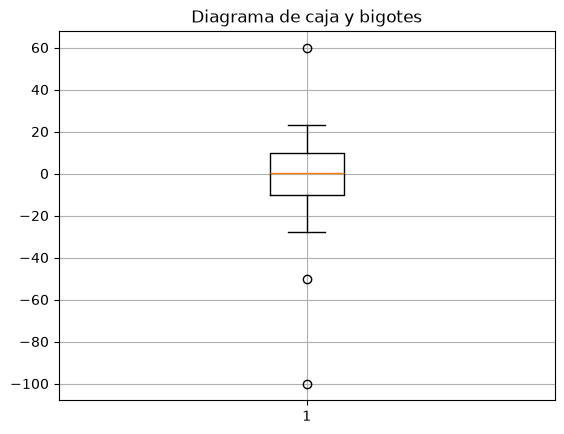

In [4]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de␣outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()

In [5]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [7]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))
if curtosis>0:
   print('Distribución Leptocúrtica')
elif curtosis<0:
   print('Distribución Platicúrtica')
else:
   print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [9]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint


iris = datasets.load_iris()
pprint(iris)
X = iris.data
y = iris.target

# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
#???

# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según␣su curtosis?
#???

{'DESCR': '.. _iris_dataset:\n'
          '\n'
          'Iris plants dataset\n'
          '--------------------\n'
          '\n'
          '**Data Set Characteristics:**\n'
          '\n'
          ':Number of Instances: 150 (50 in each of three classes)\n'
          ':Number of Attributes: 4 numeric, predictive attributes and the '
          'class\n'
          ':Attribute Information:\n'
          '    - sepal length in cm\n'
          '    - sepal width in cm\n'
          '    - petal length in cm\n'
          '    - petal width in cm\n'
          '    - class:\n'
          '            - Iris-Setosa\n'
          '            - Iris-Versicolour\n'
          '            - Iris-Virginica\n'
          '\n'
          ':Summary Statistics:\n'
          '\n'
          '============== ==== ==== ======= ===== ====================\n'
          '                Min  Max   Mean    SD   Class Correlation\n'
          '============== ==== ==== ======= ===== ====================\n'
          '

Asimetría (longitud del pétalo): -0.2721

La variable presenta una asimetría negativa (sesgo hacia la izquierda).

Curtosis (ancho del sépalo): 0.1810

La distribución es leptocúrtica.

In [10]:
# Cargar el set de datos de Iris
from sklearn import datasets
from scipy.stats import skew, kurtosis

# Cargar datos
iris = datasets.load_iris()

# Matriz de características
X = iris.data

# Variables:
# X[:,0] = longitud del sépalo
# X[:,1] = ancho del sépalo
# X[:,2] = longitud del pétalo
# X[:,3] = ancho del pétalo

# Calcular la asimetría de la longitud del pétalo
asimetria = skew(X[:, 2])

# Calcular la curtosis del ancho del sépalo
curt = kurtosis(X[:, 1])

print("Asimetría (longitud del pétalo):", round(asimetria, 4))
print("Curtosis (ancho del sépalo):", round(curt, 4))

# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
if asimetria < 0:
    print("La variable presenta una asimetría negativa (sesgo hacia la izquierda).")
elif asimetria > 0:
    print("La variable presenta una asimetría positiva (sesgo hacia la derecha).")
else:
    print("La distribución es simétrica.")

# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?
if curt > 0:
    print("La distribución es leptocúrtica.")
elif curt < 0:
    print("La distribución es platicúrtica.")
else:
    print("La distribución es mesocúrtica.")

Asimetría (longitud del pétalo): -0.2721
Curtosis (ancho del sépalo): 0.181
La variable presenta una asimetría negativa (sesgo hacia la izquierda).
La distribución es leptocúrtica.


In [11]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la␣clase y representarlo en un gráfico (plt.errorbar)

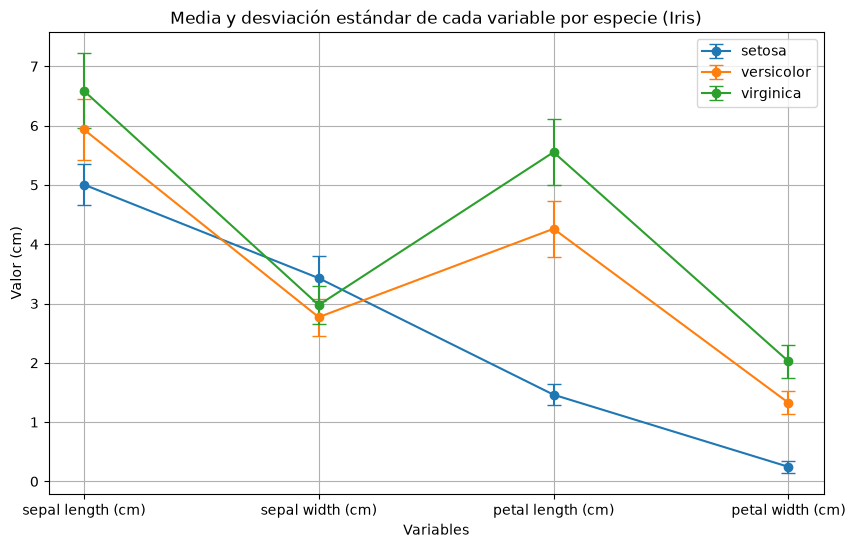

In [12]:
# EJERCICIO EXTRA SOBRE EL DATASET IRIS
# Extraer la media y la desviación típica de cada variable
# en función de la clase y representarlo en un gráfico (plt.errorbar)

from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset Iris
iris = datasets.load_iris()

# Crear DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Añadir la especie (clase)
df['species'] = iris.target

# Cambiar números por nombres
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# Calcular media por especie
medias = df.groupby('species').mean()

# Calcular desviación estándar por especie
desv = df.groupby('species').std()

# Variables del dataset
variables = iris.feature_names

# Crear gráfico
plt.figure(figsize=(10, 6))

# Dibujar una línea con barras de error para cada especie
for especie in medias.index:
    plt.errorbar(
        variables,
        medias.loc[especie],
        yerr=desv.loc[especie],
        marker='o',
        capsize=5,
        label=especie
    )

# Personalizar gráfico
plt.title('Media y desviación estándar de cada variable por especie (Iris)')
plt.xlabel('Variables')
plt.ylabel('Valor (cm)')
plt.legend()
plt.grid(True)

plt.show()